# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

\[
P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b
\]

где \(\sigma(z)\) — сигмоида:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

\[
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
\]

### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

In [49]:
df = pd.read_csv('data.csv')
display(df.head())
df.info()
display(df.describe())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Пропуски по признакам:


Unnamed: 32                569
concavity_se                 0
fractal_dimension_worst      0
symmetry_worst               0
concave points_worst         0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
concave points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


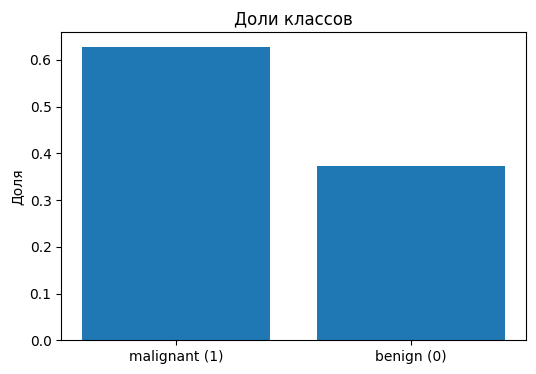

In [50]:
df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending=False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize=True).sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["malignant (1)", "benign (0)"], class_share.values)
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 31)
Test shape: (114, 31)


/Users/zakhar/ML/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/zakhar/ML/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/zakhar/ML/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [52]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))
print("sigmoid(1000) =", sigmoid(1000))
print("sigmoid(-1000) =", sigmoid(-1000))

sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]
sigmoid(1000) = 1.0
sigmoid(-1000) = 7.124576406741285e-218


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

In [53]:
def compute_log_loss(y_true, y_pred_proba):
    y_true = np.array(y_true).flatten()
    y_pred_proba = np.array(y_pred_proba).flatten()
    
    p = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
    
    if np.any(np.isnan(p)):
        print("WARNING: NaN in probabilities, replacing with 0.5")
        p = np.nan_to_num(p, nan=0.5)
    
    loss = -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
    
    if np.isnan(loss) or np.isinf(loss):
        print("WARNING: Invalid loss, returning 0.693")
        return 0.693
    
    return loss

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))

Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
- \(z = Xw + b\)
- \(\hat{p} = \sigma(z)\)

Градиенты для log-loss:
\[
dw = 
rac{1}{n} X^T(\hat{p} - y), \qquad db = 
rac{1}{n}\sum(\hat{p} - y)
\]

Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты `dw`, `db`.

In [54]:
def forward_backward(X, y, w, b):
    n = X.shape[0]
    
    X = np.nan_to_num(X, nan=0.0)
    y = np.array(y).flatten()
    y = np.nan_to_num(y, nan=0.0)
    
    z = X @ w + b
    z = np.nan_to_num(z, nan=0.0)
    
    p = sigmoid(z)
    p = np.nan_to_num(p, nan=0.5)
    
    loss = compute_log_loss(y, p)
    
    error = p - y
    error = np.nan_to_num(error, nan=0.0)
    
    dw = (X.T @ error) / n
    db = np.mean(error)
    
    dw = np.nan_to_num(dw, nan=0.0)
    db = 0.0 if np.isnan(db) else db
    
    return p, loss, dw, db

n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)
print("Есть ли NaN в p0?", np.any(np.isnan(p0)))
print("Средняя вероятность:", np.mean(p0))

Initial loss: 0.6931471805599453
dw shape: (31,)
db: 0.12637362637362637
Есть ли NaN в p0? False
Средняя вероятность: 0.5


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [55]:
class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        
        for i in range(self.n_iters):
            p, loss, dw, db = forward_backward(X, y, self.w, self.b)
            self.loss_history.append(loss)
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
            if i % 500 == 0:
                print(f"Итерация {i}, loss: {loss:.6f}")
        
        return self

    def predict_proba(self, X):
        X = np.nan_to_num(X, nan=0.0)
        z = X @ self.w + self.b
        return sigmoid(z)

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba >= self.threshold).astype(int)

## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

Итерация 0, loss: 0.693147
Итерация 500, loss: 0.069463
Итерация 1000, loss: 0.060825
Итерация 1500, loss: 0.056584
Итерация 2000, loss: 0.053849
Итерация 2500, loss: 0.051861
Итерация 3000, loss: 0.050310
Итерация 3500, loss: 0.049039
Итерация 4000, loss: 0.047957
Итерация 4500, loss: 0.047012


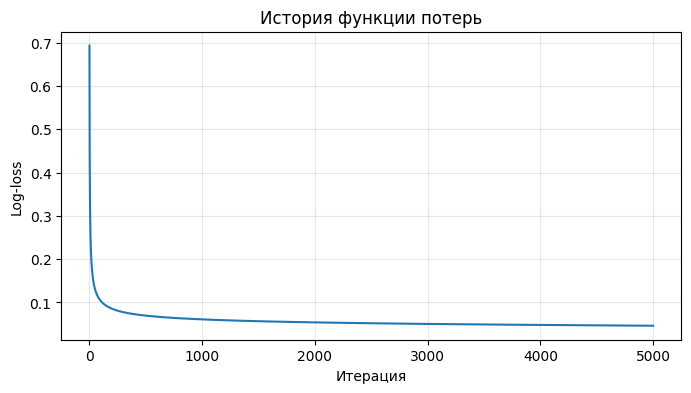

Финальный loss: 0.046170


In [56]:
my_model = MyLogisticRegressionGD(
    learning_rate=0.1,
    n_iters=5000,
    threshold=0.5
)

my_model.fit(X_train_scaled, y_train.values)

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Финальный loss: {my_model.loss_history[-1]:.6f}")

## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

In [57]:
my_proba_test = my_model.predict_proba(X_test_scaled)
my_pred_test = my_model.predict(X_test_scaled)

my_metrics = {
    "accuracy": accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall": recall_score(y_test, my_pred_test),
    "f1": f1_score(y_test, my_pred_test),
    "roc_auc": roc_auc_score(y_test, my_proba_test),
}

print("Метрики моей модели:")
pd.Series(my_metrics).round(4)

Метрики моей модели:


accuracy     0.9737
precision    0.9756
recall       0.9524
f1           0.9639
roc_auc      0.9937
dtype: float64

## Шаг 8. Confusion matrix и ROC-кривая

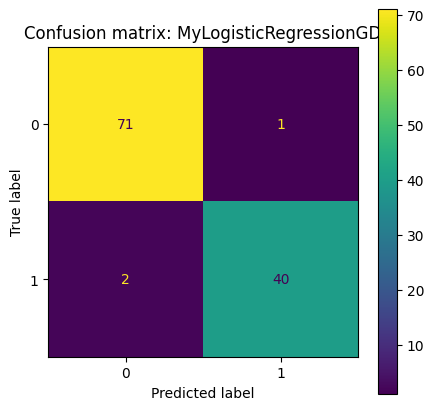

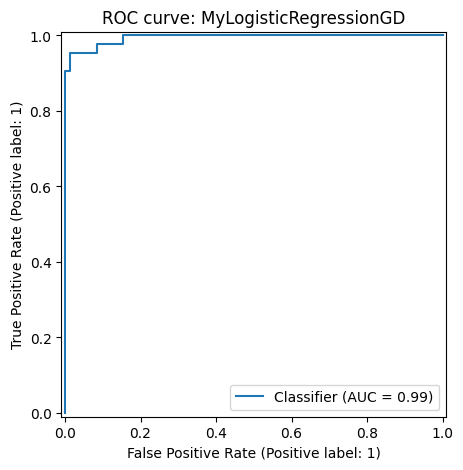

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [58]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, my_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, my_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

In [ ]:
from sklearn.impute import SimpleImputer

X_train_clean = np.nan_to_num(X_train_scaled, nan=0.0)
X_test_clean = np.nan_to_num(X_test_scaled, nan=0.0)

print("NaN после очистки в X_train_clean:", np.any(np.isnan(X_train_clean)))
print("NaN после очистки в X_test_clean:", np.any(np.isnan(X_test_clean)))

sk_model = LogisticRegression(max_iter=1000, random_state=42)
sk_model.fit(X_train_clean, y_train)

sk_proba_test = sk_model.predict_proba(X_test_clean)[:, 1]
sk_pred_test = sk_model.predict(X_test_clean)

sk_metrics = {
    "accuracy": accuracy_score(y_test, sk_pred_test),
    "precision": precision_score(y_test, sk_pred_test),
    "recall": recall_score(y_test, sk_pred_test),
    "f1": f1_score(y_test, sk_pred_test),
    "roc_auc": roc_auc_score(y_test, sk_proba_test),
}

print("Метрики модели sklearn:")
pd.Series(sk_metrics).round(4)

NaN после очистки в X_train_clean: False
NaN после очистки в X_test_clean: False
Метрики модели sklearn:


accuracy     0.9649
precision    0.9750
recall       0.9286
f1           0.9512
roc_auc      0.9960
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

In [60]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9737,0.9756,0.9524,0.9639,0.9937
sklearn,0.9649,0.9750,0.9286,0.9512,0.9960


,feature,my_coef,sklearn_coef,abs_diff
10,radius_se,1.747878,1.233325,0.514552
15,compactness_se,-1.370529,-0.906925,0.463604
21,texture_worst,1.826967,1.434093,0.392874
28,symmetry_worst,1.446256,1.061264,0.384992
13,area_se,1.247421,0.909029,0.338392
12,perimeter_se,1.067866,0.748295,0.319571
19,fractal_dimension_se,-0.901518,-0.593876,0.307642
26,concavity_worst,1.212600,0.911406,0.301194
27,concave points_worst,0.974929,0.703999,0.270930
5,compactness_mean,-0.708496,-0.439546,0.268950


## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

In [61]:
thresholds = [0.3, 0.5, 0.7]
rows = []

for threshold in thresholds:
    pred_thr = (my_proba_test >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr),
        "recall": recall_score(y_test, pred_thr),
        "f1": f1_score(y_test, pred_thr),
    })

pd.DataFrame(rows).round(4)

,threshold,accuracy,precision,recall,f1
0,0.3,0.9737,0.9756,0.9524,0.9639
1,0.5,0.9737,0.9756,0.9524,0.9639
2,0.7,0.9649,1.0000,0.9048,0.9500


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. Почему для логистической регрессии используется сигмоида?

Сигмоида нужна нам для того чтобы переводить числа в интевал (0,1), что интерпретируется как веротность. 

2. Почему в этой задаче мы считаем **log-loss**, а не MSE?

мсе имеет локальные минимумы что может сбить с толку градиентный спуск 

3. Зачем стандартизировать признаки перед обучением градиентным спуском?

С маленькими весами он работает быстрее тк чем больше вес тем больше градиент и он будет дольше прыгать пока ищет

4. Насколько близки метрики вашей реализации к `scikit-learn`?

Почти одно и то же

5. Почему библиотечная модель обычно работает стабильнее и быстрее?

Она использует более сложные алгоритмы оптимизации которые работают за меньшее количество итераций. Там также есть регуляризация 

6. Как изменение порога влияет на precision и recall?

если >0.5 то растет percision а рекол падает если <0.5 то наоборот

7. В каких задачах логистическая регрессия особенно хороша, а где может уступать более сложным моделям?

Хороша в бинарной класификации, где надо интерпретировать 
Плоха при нелинейных зависимостях, обработке языка 


## ВЫВОДЫ

насколько близки метрики вашей модели и `scikit-learn`

    одно и то же почти

Где ваша реализация может уступать библиотечной?

    корость, нет регуляризации и просто больше возможностей как мультиклассовая класификация

Как влияет изменение порога классификации?
    
    если >0.5 то растет percision а рекол падает если <0.5 то наоборот


## Дополнительные задания

### Задание A
Добавьте L2-регуляризацию в свою реализацию.

### Задание B
Постройте таблицу с 10 признаками, которые дают наибольший по модулю вклад в модель.

### Задание C
Попробуйте:
- уменьшить число итераций;
- изменить `learning_rate`;
- посмотреть, как это влияет на сходимость и метрики.

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- стандартизация;
- реализация логистической регрессии с нуля;
- обучение;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ порога классификации;
- выводы.

Не сдавайте ноутбук без текстовых выводов.